# Regresión Lineal con PyTorch

<a href="https://colab.research.google.com/github/andrescastro-itm/pytorch_resources/blob/main/3_RegresionLineal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

En este notebook, implementaremos regresión lineal de dos formas diferentes usando PyTorch:
1. **Implementación Manual**: Creando los pesos y bias desde cero, calculando la pérdida manualmente y actualizando los parámetros paso a paso
2. **Implementación con PyTorch API**: Utilizando módulos como `nn.Linear`, funciones de pérdida incorporadas y optimizadores

Comenzaremos creando un conjunto de datos sintético para nuestros ejemplos.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# Configuración para reproducibilidad
torch.manual_seed(42)
np.random.seed(42)

# Configuramos matplotlib
%matplotlib inline
plt.style.use('ggplot')

## Generación del Conjunto de Datos Sintético

Crearemos un conjunto de datos sintético basado en una relación lineal $y = wx + b + \text{ruido}$.

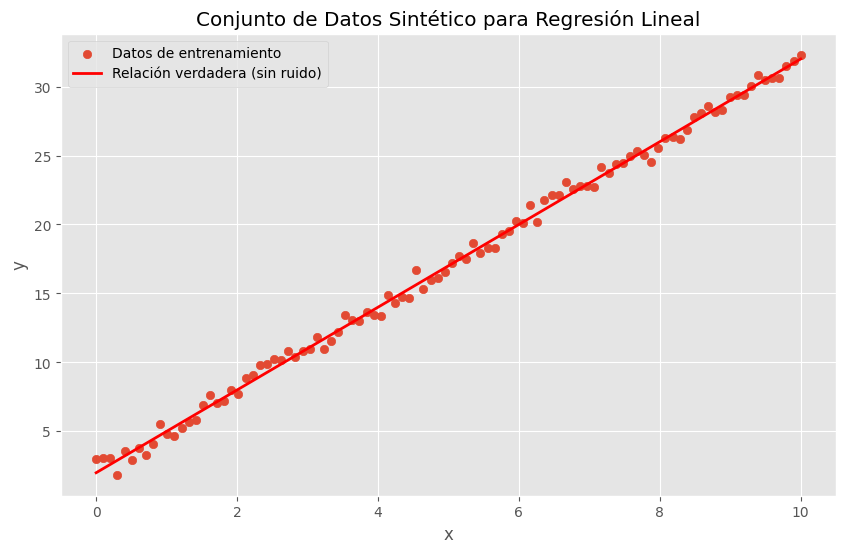

Parámetros verdaderos: w = 3.0, b = 2.0


In [2]:
# Parámetros reales que queremos descubrir con nuestro modelo
w_true = 3.0
b_true = 2.0

# Creamos datos sintéticos
x = torch.linspace(0, 10, steps=100).reshape(-1, 1)  # 100 valores entre 0 y 10
y_clean = w_true * x + b_true
noise = torch.randn(x.shape) * 0.5             # Ruido gaussiano
y = y_clean + noise                # Valores observados con ruido

# Visualizamos los datos
plt.figure(figsize=(10, 6))
plt.scatter(x.numpy(), y.numpy(), label='Datos de entrenamiento')
plt.plot(x.numpy(), y_clean.numpy(), 'r-', linewidth=2, label='Relación verdadera (sin ruido)')
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.title('Conjunto de Datos Sintético para Regresión Lineal')
plt.grid(True)
plt.show()

print(f"Parámetros verdaderos: w = {w_true}, b = {b_true}")

## 1. Implementación Manual de Regresión Lineal con PyTorch

En esta sección, implementaremos regresión lineal de forma manual utilizando tensores PyTorch con `requires_grad=True` para el seguimiento automático de gradientes.

In [3]:
# Inicializamos parámetros con valores aleatorios
w = torch.randn(1, requires_grad=True)  # Un solo parámetro de peso
b = torch.randn(1, requires_grad=True)  # Un solo parámetro de sesgo (bias)

print(f"Parámetros iniciales: w = {w.item():.4f}, b = {b.item():.4f}")

Parámetros iniciales: w = -0.5672, b = -0.5706


### Definición de la Función Modelo, Función de Pérdida y Actualización de Parámetros

In [4]:
# Hiperparámetros
learning_rate = 0.01
n_epochs = 1000

# Listas para almacenar el historial de pérdida y parámetros
loss_history = []
w_history = []
b_history = []

# Entrenamiento
for epoch in range(n_epochs):
    # Forward pass: Predecimos y
    y_pred = w * x + b

    # Calculamos la pérdida (error cuadrático medio - MSE)
    loss = ((y_pred - y) ** 2).mean()

    # Guardamos historial
    loss_history.append(loss.item())
    w_history.append(w.item())
    b_history.append(b.item())

    # Backward pass: Calculamos gradientes
    loss.backward()

    # Actualización manual de parámetros (descenso de gradiente)
    with torch.no_grad():  # Deshabilitamos el seguimiento de gradientes para la actualización
        w -= learning_rate * w.grad
        b -= learning_rate * b.grad

        # Reiniciamos gradientes a cero para la siguiente iteración
        w.grad.zero_()
        b.grad.zero_()

    # Imprimimos progreso cada 20 épocas
    if epoch % 20 == 0 or epoch == n_epochs - 1:
        print(f"Época {epoch+1}/{n_epochs}, Pérdida: {loss.item():.6f}, w: {w.item():.4f}, b: {b.item():.4f}")

Época 1/1000, Pérdida: 525.891846, w: 2.0825, b: -0.1619
Época 21/1000, Pérdida: 1.100725, w: 3.2725, b: 0.2130
Época 41/1000, Pérdida: 0.945500, w: 3.2464, b: 0.3865
Época 61/1000, Pérdida: 0.818292, w: 3.2227, b: 0.5436
Época 81/1000, Pérdida: 0.714045, w: 3.2014, b: 0.6858
Época 101/1000, Pérdida: 0.628613, w: 3.1820, b: 0.8145
Época 121/1000, Pérdida: 0.558602, w: 3.1645, b: 0.9311
Época 141/1000, Pérdida: 0.501227, w: 3.1486, b: 1.0366
Época 161/1000, Pérdida: 0.454208, w: 3.1343, b: 1.1321
Época 181/1000, Pérdida: 0.415676, w: 3.1213, b: 1.2185
Época 201/1000, Pérdida: 0.384098, w: 3.1095, b: 1.2968
Época 221/1000, Pérdida: 0.358220, w: 3.0988, b: 1.3676
Época 241/1000, Pérdida: 0.337013, w: 3.0892, b: 1.4317
Época 261/1000, Pérdida: 0.319634, w: 3.0805, b: 1.4898
Época 281/1000, Pérdida: 0.305391, w: 3.0726, b: 1.5424
Época 301/1000, Pérdida: 0.293720, w: 3.0654, b: 1.5899
Época 321/1000, Pérdida: 0.284155, w: 3.0589, b: 1.6330
Época 341/1000, Pérdida: 0.276316, w: 3.0531, b: 1.

### Visualización de Resultados de la Implementación Manual

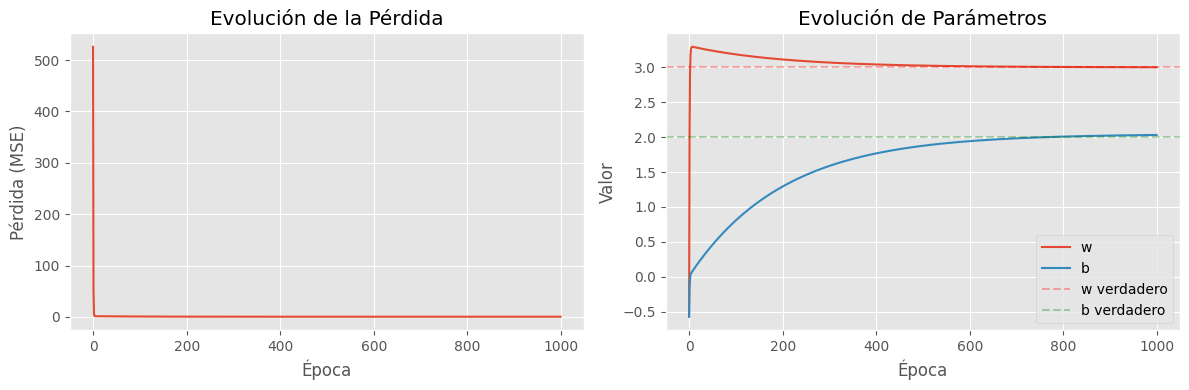

In [5]:
# Graficamos la evolución de la pérdida
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(loss_history)
plt.title('Evolución de la Pérdida')
plt.xlabel('Época')
plt.ylabel('Pérdida (MSE)')
plt.grid(True)

# Graficamos la evolución de los parámetros
plt.subplot(1, 2, 2)
plt.plot(w_history, label='w')
plt.plot(b_history, label='b')
plt.axhline(y=w_true, color='r', linestyle='--', alpha=0.3, label='w verdadero')
plt.axhline(y=b_true, color='g', linestyle='--', alpha=0.3, label='b verdadero')
plt.title('Evolución de Parámetros')
plt.xlabel('Época')
plt.ylabel('Valor')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

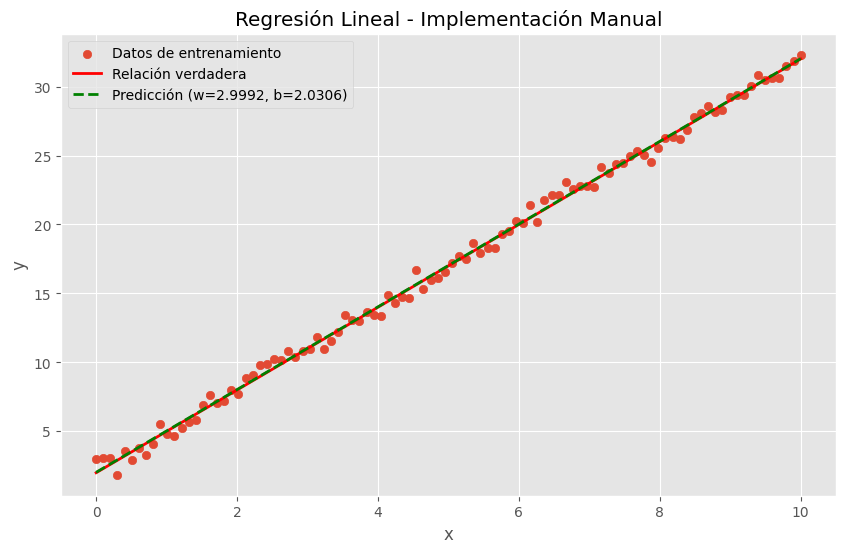

In [6]:
# Visualizamos el ajuste final
plt.figure(figsize=(10, 6))
plt.scatter(x.numpy(), y.numpy(), label='Datos de entrenamiento')
plt.plot(x.numpy(), y_clean.numpy(), 'r-', linewidth=2, label='Relación verdadera')

# Línea de predicción del modelo entrenado manualmente
y_pred = w * x + b
plt.plot(x.numpy(), y_pred.detach().numpy(), 'g--', linewidth=2,
         label=f'Predicción (w={w.item():.4f}, b={b.item():.4f})')

plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.title('Regresión Lineal - Implementación Manual')
plt.grid(True)
plt.show()

## 2. Implementación con PyTorch API

Ahora implementaremos el mismo problema utilizando las abstracciones de alto nivel proporcionadas por PyTorch: `nn.Module`, funciones de pérdida incorporadas y optimizadores.

In [7]:
import torch.nn as nn
import torch.optim as optim

# Definimos el modelo de regresión lineal usando nn.Module
class LinearRegression(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(LinearRegression, self).__init__()
        # nn.Linear incluye automáticamente el bias (sesgo)
        self.linear = nn.Linear(input_dim, output_dim)

    def forward(self, x):
        return self.linear(x)

# Creamos instancia del modelo
input_dim = 1    # Dimensión de entrada (x)
output_dim = 1   # Dimensión de salida (y)
model = LinearRegression(input_dim, output_dim)

# Definimos la función de pérdida
criterion = nn.MSELoss()

# Definimos el optimizador
optimizer = optim.SGD(model.parameters(), lr=0.01)

# Imprimimos los parámetros iniciales
for name, param in model.named_parameters():
    print(f"Parámetro inicial {name}: {param.data.numpy().reshape(-1)}")  # Convertimos a numpy para visualización

Parámetro inicial linear.weight: [0.00277126]
Parámetro inicial linear.bias: [-0.3721032]


### Entrenamiento del Modelo con PyTorch API

In [8]:
# Hiperparámetros
n_epochs = 1000

# Listas para almacenar el historial
loss_history_api = []
w_history_api = []
b_history_api = []

# Entrenamiento
for epoch in range(n_epochs):
    # Forward pass
    y_pred = model(x)

    # Cálculo de pérdida
    loss = criterion(y_pred, y)

    # Guardamos historial
    loss_history_api.append(loss.item())
    w_history_api.append(model.linear.weight.item())
    b_history_api.append(model.linear.bias.item())

    # Backward pass y optimización
    optimizer.zero_grad()  # Reiniciamos gradientes
    loss.backward()        # Retropropagación
    optimizer.step()       # Actualizamos parámetros

    # Imprimimos progreso cada 20 épocas
    if epoch % 20 == 0 or epoch == n_epochs - 1:
        print(f"Época {epoch+1}/{n_epochs}, Pérdida: {loss.item():.6f}, "
              f"w: {model.linear.weight.item():.4f}, b: {model.linear.bias.item():.4f}")

Época 1/1000, Pérdida: 378.811493, w: 2.2507, b: -0.0243
Época 21/1000, Pérdida: 1.009913, w: 3.2575, b: 0.3124
Época 41/1000, Pérdida: 0.871079, w: 3.2328, b: 0.4765
Época 61/1000, Pérdida: 0.757304, w: 3.2105, b: 0.6251
Época 81/1000, Pérdida: 0.664065, w: 3.1903, b: 0.7595
Época 101/1000, Pérdida: 0.587654, w: 3.1720, b: 0.8813
Época 121/1000, Pérdida: 0.525036, w: 3.1554, b: 0.9915
Época 141/1000, Pérdida: 0.473720, w: 3.1404, b: 1.0913
Época 161/1000, Pérdida: 0.431666, w: 3.1268, b: 1.1816
Época 181/1000, Pérdida: 0.397202, w: 3.1145, b: 1.2633
Época 201/1000, Pérdida: 0.368959, w: 3.1034, b: 1.3374
Época 221/1000, Pérdida: 0.345814, w: 3.0933, b: 1.4044
Época 241/1000, Pérdida: 0.326846, w: 3.0842, b: 1.4650
Época 261/1000, Pérdida: 0.311302, w: 3.0759, b: 1.5199
Época 281/1000, Pérdida: 0.298563, w: 3.0685, b: 1.5696
Época 301/1000, Pérdida: 0.288124, w: 3.0617, b: 1.6146
Época 321/1000, Pérdida: 0.279569, w: 3.0556, b: 1.6554
Época 341/1000, Pérdida: 0.272558, w: 3.0500, b: 1.

### Visualización de Resultados con PyTorch API

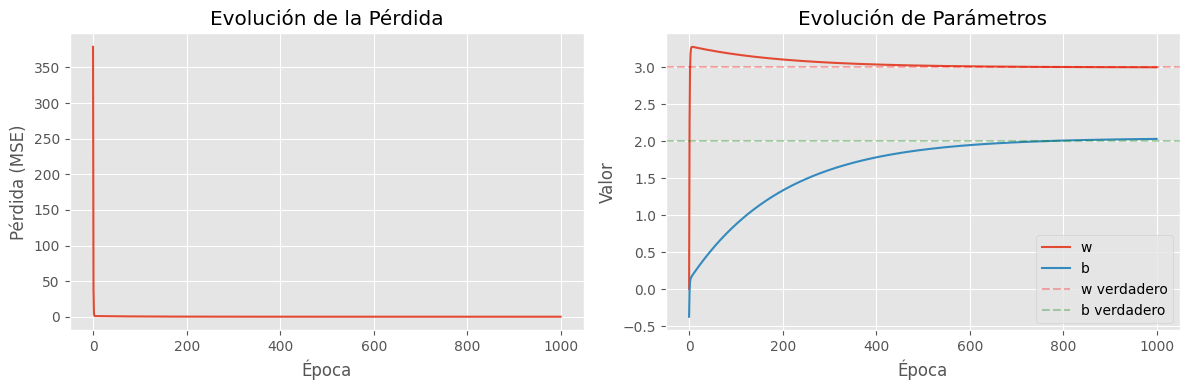

In [9]:
# Graficamos la evolución de la pérdida
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(loss_history_api)
plt.title('Evolución de la Pérdida')
plt.xlabel('Época')
plt.ylabel('Pérdida (MSE)')
plt.grid(True)

# Graficamos la evolución de los parámetros
plt.subplot(1, 2, 2)
plt.plot(w_history_api, label='w')
plt.plot(b_history_api, label='b')
plt.axhline(y=w_true, color='r', linestyle='--', alpha=0.3, label='w verdadero')
plt.axhline(y=b_true, color='g', linestyle='--', alpha=0.3, label='b verdadero')
plt.title('Evolución de Parámetros')
plt.xlabel('Época')
plt.ylabel('Valor')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

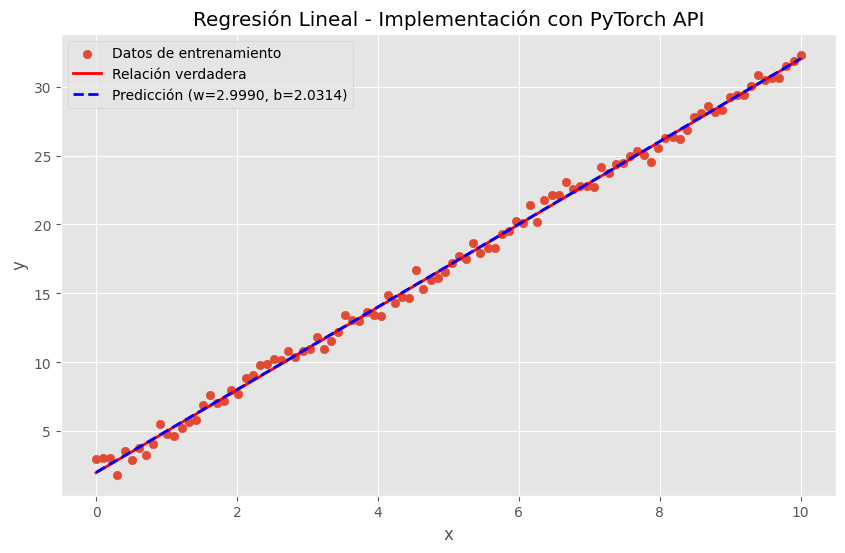

In [10]:
# Visualizamos el ajuste final
plt.figure(figsize=(10, 6))
plt.scatter(x.numpy(), y.numpy(), label='Datos de entrenamiento')
plt.plot(x.numpy(), y_clean.numpy(), 'r-', linewidth=2, label='Relación verdadera')

# Línea de predicción del modelo entrenado con API
with torch.no_grad():
    y_pred_api = model(x)
plt.plot(x.numpy(), y_pred_api.numpy(), 'b--', linewidth=2,
         label=f'Predicción (w={model.linear.weight.item():.4f}, b={model.linear.bias.item():.4f})')

plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.title('Regresión Lineal - Implementación con PyTorch API')
plt.grid(True)
plt.show()

## Comparación de las Dos Implementaciones

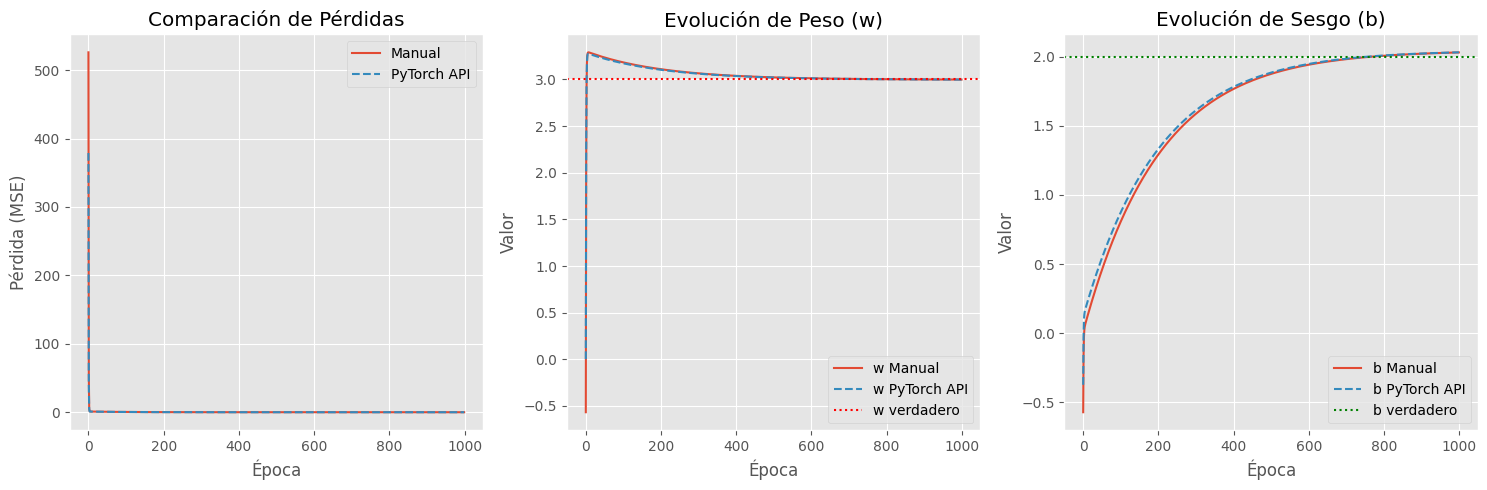

In [11]:
# Comparamos la evolución de los parámetros en ambas implementaciones
plt.figure(figsize=(15, 5))

# Comparación de pérdidas
plt.subplot(1, 3, 1)
plt.plot(loss_history, label='Manual')
plt.plot(loss_history_api, label='PyTorch API', linestyle='--')
plt.title('Comparación de Pérdidas')
plt.xlabel('Época')
plt.ylabel('Pérdida (MSE)')
plt.legend()
plt.grid(True)

# Comparación de pesos (w)
plt.subplot(1, 3, 2)
plt.plot(w_history, label='w Manual')
plt.plot(w_history_api, label='w PyTorch API', linestyle='--')
plt.axhline(y=w_true, color='r', linestyle=':', label='w verdadero')
plt.title('Evolución de Peso (w)')
plt.xlabel('Época')
plt.ylabel('Valor')
plt.legend()
plt.grid(True)

# Comparación de sesgos (b)
plt.subplot(1, 3, 3)
plt.plot(b_history, label='b Manual')
plt.plot(b_history_api, label='b PyTorch API', linestyle='--')
plt.axhline(y=b_true, color='g', linestyle=':', label='b verdadero')
plt.title('Evolución de Sesgo (b)')
plt.xlabel('Época')
plt.ylabel('Valor')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Conclusiones

### Implementación Manual
* Nos permite entender lo que ocurre "bajo el capó" en regresión lineal
* Requiere escribir más código para gestionar parámetros, pérdida y optimización
* Mayor control sobre cada paso del proceso
* Útil para fines educativos y personalización avanzada

### Implementación con PyTorch API
* Más concisa y menos propensa a errores
* Aprovecha optimizaciones incorporadas y abstracciones bien probadas
* Mejor para modelos complejos y producción
* Facilita la extensión a arquitecturas más complejas

Ambas implementaciones convergen a valores muy similares, cercanos a los parámetros verdaderos:
* $w_{verdadero} = 3.0$ y $b_{verdadero} = 2.0$
